# Importam toate librariile necesare

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Citim datasetul necesare dintr-ul fisier CSV

In [21]:
data_file_path = "../dataset/date_activitate_fizica.csv"

df = pd.read_csv(data_file_path)
N = len(df)

# Descrierea generala a datasetului

In [18]:
with pd.option_context("display.max_columns", 8, "display.width", 800):
    print("Shape: ", df.shape)
    print()
    print("Details: \n", df[["Varsta", "Numar_Pasi_Zilnic", "Timp_Liber_Activ"]].describe())
    print()
    print("Head with 10 records: \n", df.head(10))

Shape:  (100, 7)

Details: 
            Varsta  Numar_Pasi_Zilnic  Timp_Liber_Activ
count  100.000000         100.000000        100.000000
mean    39.620000        7550.650000          2.237000
std     13.100837        2180.955955          2.231123
min     18.000000        1500.000000          0.000000
25%     29.000000        6015.500000          0.600000
50%     41.000000        7538.500000          1.500000
75%     47.000000        9071.000000          3.000000
max     70.000000       12832.000000         11.700000

Head with 10 records: 
    ID       Sex  Varsta Tip_Localitate  Numar_Pasi_Zilnic   Tip_Ocupatie  Timp_Liber_Activ
0   1  Masculin      41          Rural              10667       Sedentar               0.4
1   2   Feminin      35          Urban               5730  Moderat_Activ               0.1
2   3   Feminin      41          Urban               8609       Sedentar               4.2
3   4   Feminin      18          Urban               9436       Sedentar               

# Distributia dupa variabila calitative

In [45]:
def tabel_distributie(coloana):
    freq_abs = df[coloana].value_counts().sort_index()
    freq_rel = (freq_abs / len(df) * 100).round(2)
    
    tabel = pd.DataFrame({
        'Frecvență': freq_abs,
        'Pondere (%)': freq_rel
    })
    
    tabel.loc['Total'] = [freq_abs.sum(), freq_rel.sum()]
    return (tabel, freq_abs)

def pie_chart_distributie(freq_abs, title, file_path):
    # Creăm pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(freq_abs, 
            labels=freq_abs.index, 
            autopct='%1.1f%%',
            startangle=90,
            #colors=['#6baed6', '#fd8d3c'],
           )  # culori neutre
    plt.title(title)
    plt.axis('equal')  # pentru cerc perfect
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()

## Distributia dupa sex

In [36]:
tabel_sex, freq_abs = tabel_distributie("Sex")
tabel_sex

,Frecvență,Pondere (%)
Sex,,
Feminin,47.0,47.0
Masculin,53.0,53.0
Total,100.0,100.0


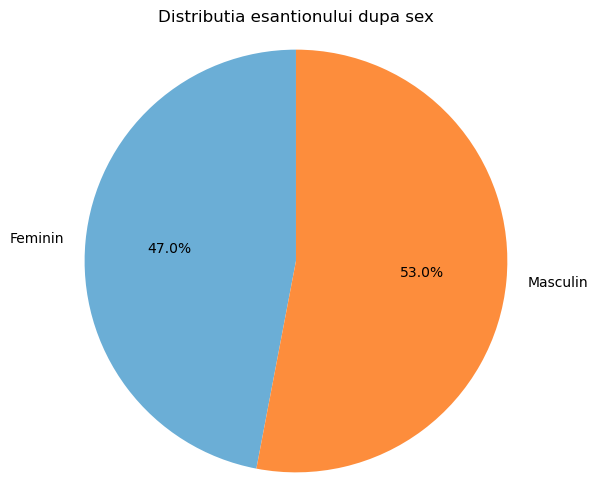

In [37]:
pie_chart_distributie(freq_abs, 'Distributia esantionului dupa sex', '../figuri/sex_distribution.pdf')

## Distributia dupa tip localitate

In [39]:
tabel, freq_abs = tabel_distributie("Tip_Localitate")
tabel

,Frecvență,Pondere (%)
Tip_Localitate,,
Rural,43.0,43.0
Urban,57.0,57.0
Total,100.0,100.0


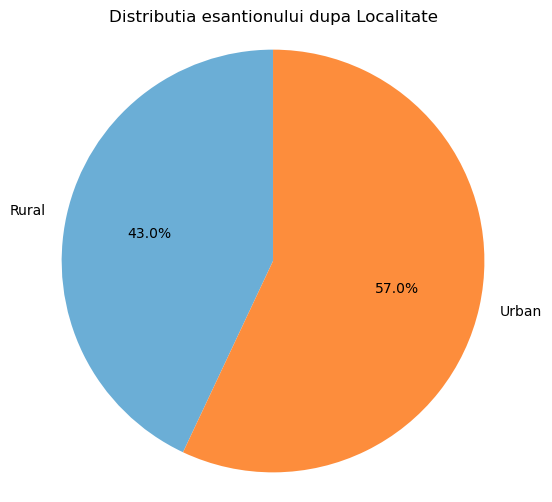

In [40]:
pie_chart_distributie(freq_abs, 'Distributia esantionului dupa Localitate', '../figuri/localitate_distr.pdf')

In [50]:
tabel, freq_abs = tabel_distributie("Tip_Ocupatie")
tabel

,Frecvență,Pondere (%)
Tip_Ocupatie,,
Activ,25.0,25.0
Casnic/a,13.0,13.0
Moderat_Activ,19.0,19.0
Pensionar,12.0,12.0
Sedentar,20.0,20.0
Student,11.0,11.0
Total,100.0,100.0


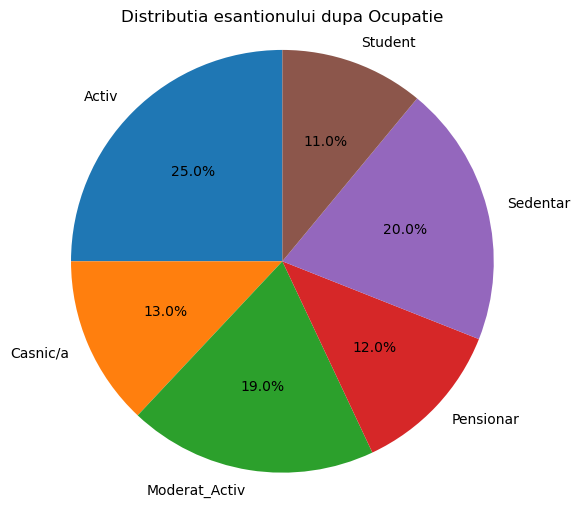

In [46]:
pie_chart_distributie(freq_abs, 'Distributia esantionului dupa Ocupatie', '../figuri/ocupatie_distr.pdf')

# Distributia dupa variabilele cantitative

## Distributia dupa varsta

In [57]:
data = df.copy()

# Interval [min, max] pentru varsta
v_min, v_max = data['Varsta'].min(), data['Varsta'].max()

# Alegem, de exemplu, 6 clase egale
# num_classes = 6
# bins = np.linspace(v_min, v_max, num_classes + 1)  # capetele claselor

# Definim manual intervale rotunde
bins = [18, 25, 35, 45, 55, 65, 75]  # capetele claselor

# Tăiem varsta pe clase
data['Varsta_clasa'] = pd.cut(data['Varsta'], bins=bins, right=False, include_lowest=True)

# Tabel de frecvențe
freq_abs = data['Varsta_clasa'].value_counts().sort_index()
freq_rel = (freq_abs / len(df) * 100).round(2)

tabel_varsta = pd.DataFrame({
    'Frecvență': freq_abs,
    'Pondere (%)': freq_rel
})

print(tabel_varsta)

              Frecvență  Pondere (%)
Varsta_clasa                        
[18, 25)             13         13.0
[25, 35)             22         22.0
[35, 45)             33         33.0
[45, 55)             21         21.0
[55, 65)              6          6.0
[65, 75)              5          5.0


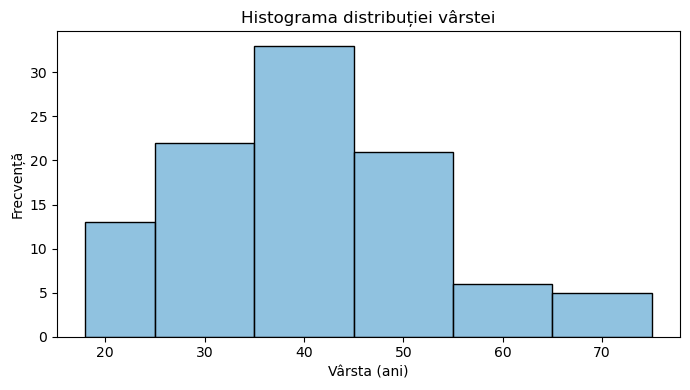

In [58]:
plt.figure(figsize=(7, 4))
sns.histplot(data['Varsta'], bins=bins, kde=False, color='#6baed6', edgecolor='black')
plt.xlabel('Vârsta (ani)')
plt.ylabel('Frecvență')
plt.title('Histograma distribuției vârstei')
plt.tight_layout()
plt.savefig('../figuri/varsta_hist.pdf', bbox_inches='tight')  # pentru LaTeX
plt.show()

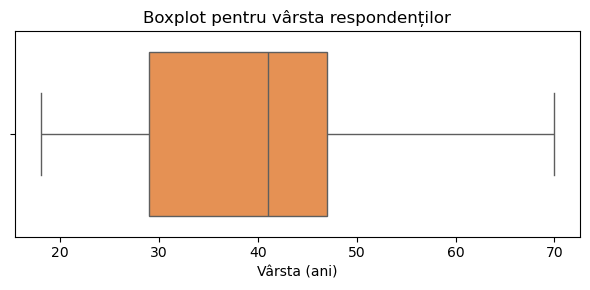

In [59]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=data['Varsta'], color='#fd8d3c')
plt.xlabel('Vârsta (ani)')
plt.title('Boxplot pentru vârsta respondenților')
plt.tight_layout()
plt.savefig('../figuri/varsta_boxplot.pdf', bbox_inches='tight')
plt.show()

## Distributia dupa numarul de pasi

In [62]:
data = df.copy()

# Calculăm numărul de bins folosind regula lui Sturges
n = len(data)
k_sturges = int(np.ceil(1 + np.log2(n)))

print(f"Număr de observații: {n}")
print(f"Număr de bins (Sturges): {k_sturges}")

# Definim intervalele pentru Numar_Pasi_Zilnic
v_min = data['Numar_Pasi_Zilnic'].min()
v_max = data['Numar_Pasi_Zilnic'].max()

# Creăm bins-urile
bins_pasi = np.linspace(v_min, v_max, k_sturges + 1)
print(f"\nIntervale generate automat:\n{bins_pasi}")

# Opțional: rotunjim bins-urile pentru a avea valori mai frumoase
# De exemplu, rotunjim la sute
bins_pasi_rotunjite = np.round(bins_pasi / 100) * 100
print(f"\nIntervale rotunjite:\n{bins_pasi_rotunjite}")

# Creăm clasa pentru fiecare observație
data['Pasi_clasa'] = pd.cut(data['Numar_Pasi_Zilnic'], bins=bins_pasi_rotunjite, right=False, include_lowest=True)

# Tabel de frecvențe
freq_abs = data['Pasi_clasa'].value_counts().sort_index()
freq_rel = (freq_abs / len(data) * 100).round(2)

tabel_pasi = pd.DataFrame({
    'Frecvență': freq_abs,
    'Pondere (%)': freq_rel
})

tabel_pasi

Număr de observații: 100
Număr de bins (Sturges): 8

Intervale generate automat:
[ 1500.   2916.5  4333.   5749.5  7166.   8582.5  9999.  11415.5 12832. ]

Intervale rotunjite:
[ 1500.  2900.  4300.  5700.  7200.  8600. 10000. 11400. 12800.]


,Frecvență,Pondere (%)
Pasi_clasa,,
"[1500.0, 2900.0)",2,2.0
"[2900.0, 4300.0)",4,4.0
"[4300.0, 5700.0)",13,13.0
"[5700.0, 7200.0)",26,26.0
"[7200.0, 8600.0)",22,22.0
"[8600.0, 10000.0)",21,21.0
"[10000.0, 11400.0)",8,8.0
"[11400.0, 12800.0)",3,3.0


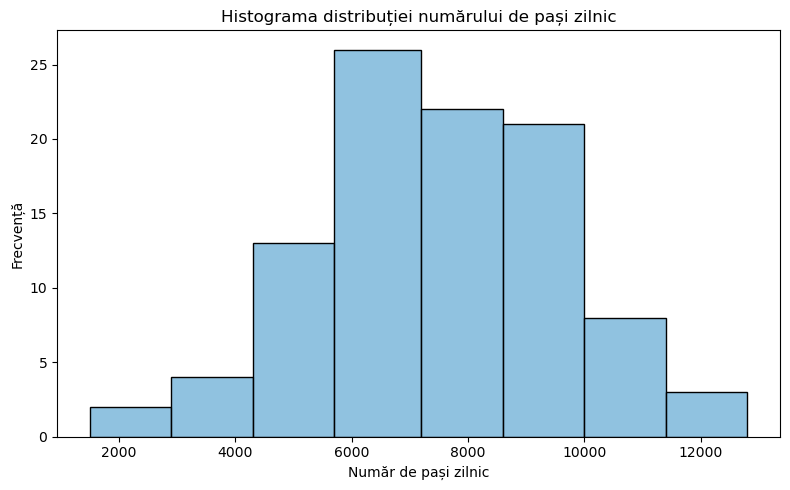

In [63]:
# Creăm histograma
plt.figure(figsize=(8, 5))
sns.histplot(data['Numar_Pasi_Zilnic'], bins=bins_pasi_rotunjite, kde=False, color='#6baed6', edgecolor='black')
plt.xlabel('Număr de pași zilnic')
plt.ylabel('Frecvență')
plt.title('Histograma distribuției numărului de pași zilnic')
plt.tight_layout()
plt.savefig('../figuri/pasi_hist.pdf', bbox_inches='tight')
plt.show()

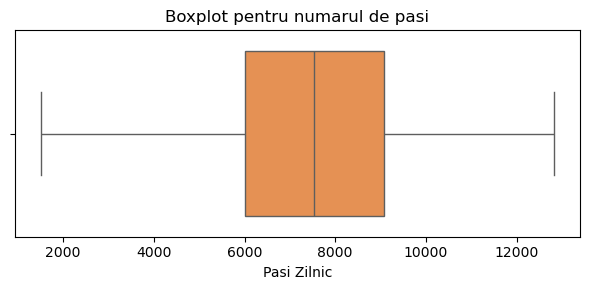

In [64]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=data['Numar_Pasi_Zilnic'], color='#fd8d3c')
plt.xlabel('Pasi Zilnic')
plt.title('Boxplot pentru numarul de pasi')
plt.tight_layout()
plt.savefig('../figuri/pasi_boxplot.pdf', bbox_inches='tight')
plt.show()

# Analiză bivariată descriptivă

## Număr mediu de pași pe zi după sex

In [67]:
group_sex = df.groupby('Sex')['Numar_Pasi_Zilnic'].agg(
    Frecvență='count',
    Medie='mean',
    Mediana='median',
    Dev_std='std'
).round(2)
print(group_sex)

          Frecvență    Medie  Mediana  Dev_std
Sex                                           
Feminin          47  7448.11   7120.0  2078.25
Masculin         53  7641.58   7783.0  2284.09


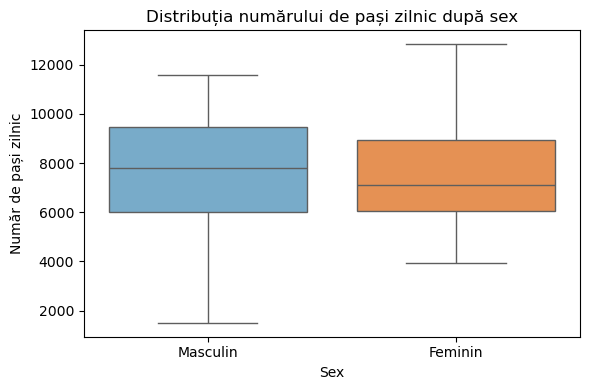

In [75]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x='Sex',
    y='Numar_Pasi_Zilnic',
    hue='Sex',
    palette=['#6baed6', '#fd8d3c'],
)
plt.xlabel('Sex')
plt.ylabel('Număr de pași zilnic')
plt.title('Distribuția numărului de pași zilnic după sex')
plt.tight_layout()
plt.savefig('../figuri/pasi_sex_boxplot.pdf', bbox_inches='tight')
plt.show()

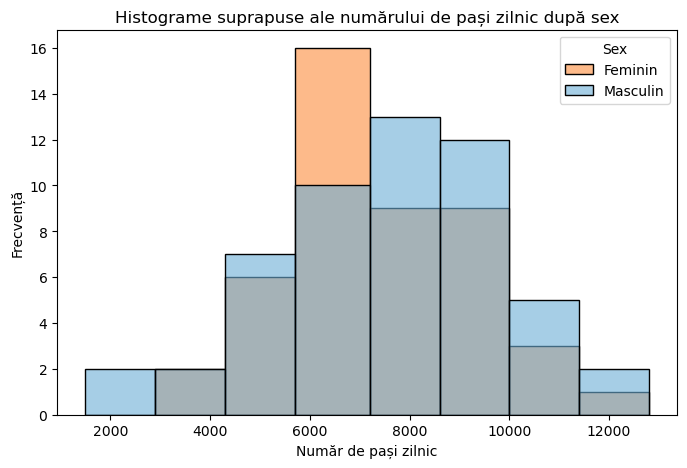

In [83]:
plt.figure(figsize=(8, 5))

# Filtrăm pe fiecare sex și desenăm separat
sns.histplot(
    data=df[df['Sex'] == 'Feminin'],
    x='Numar_Pasi_Zilnic',
    bins=bins_pasi_rotunjite,
    #kde=True,
    color='#fd8d3c',
    alpha=0.6,
    label='Feminin'
)

sns.histplot(
    data=df[df['Sex'] == 'Masculin'],
    x='Numar_Pasi_Zilnic',
    bins=bins_pasi_rotunjite,
    #kde=True,
    color='#6baed6',
    alpha=0.6,
    label='Masculin'
)

plt.xlabel('Număr de pași zilnic')
plt.ylabel('Frecvență')
plt.title('Histograme suprapuse ale numărului de pași zilnic după sex')
plt.legend(title='Sex')
#plt.tight_layout()
plt.savefig('../figuri/pasi_sex_hist_overlay.pdf', bbox_inches='tight')
plt.show()

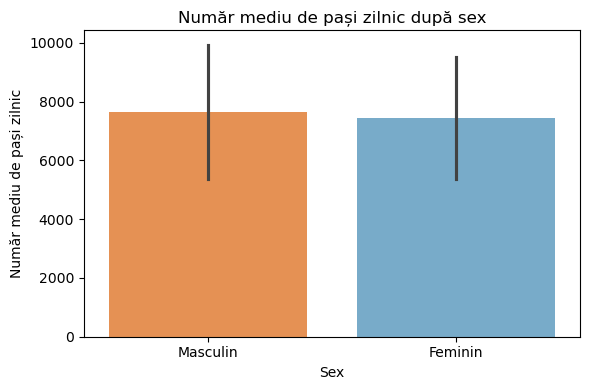

In [84]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x='Sex',
    y='Numar_Pasi_Zilnic',
    hue='Sex',
    palette=['#fd8d3c', '#6baed6'],
    errorbar='sd',  # bare de eroare = deviația standard
    legend=False
)
plt.xlabel('Sex')
plt.ylabel('Număr mediu de pași zilnic')
plt.title('Număr mediu de pași zilnic după sex')
plt.tight_layout()
plt.savefig('../figuri/pasi_sex_barplot.pdf', bbox_inches='tight')
plt.show()

## Număr mediu de pași pe zi după tip localitate

In [85]:
group_loc = df.groupby('Tip_Localitate')['Numar_Pasi_Zilnic'].agg(
    Frecvență='count',
    Medie='mean',
    Mediana='median',
    Dev_std='std'
).round(2)

print(group_loc)

                Frecvență    Medie  Mediana  Dev_std
Tip_Localitate                                      
Rural                  43  7622.72   7525.0  2106.38
Urban                  57  7496.28   7552.0  2252.62


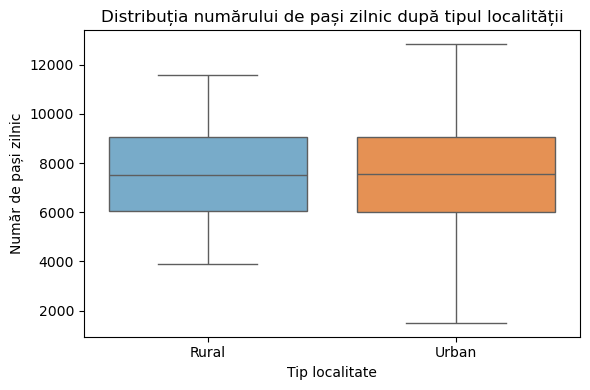

In [86]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x='Tip_Localitate',
    y='Numar_Pasi_Zilnic',
    hue='Tip_Localitate',
    palette=['#6baed6', '#fd8d3c'],
    dodge=False,
    legend=False
)
plt.xlabel('Tip localitate')
plt.ylabel('Număr de pași zilnic')
plt.title('Distribuția numărului de pași zilnic după tipul localității')
plt.tight_layout()
plt.savefig('../figuri/pasi_localitate_boxplot.pdf', bbox_inches='tight')
plt.show()

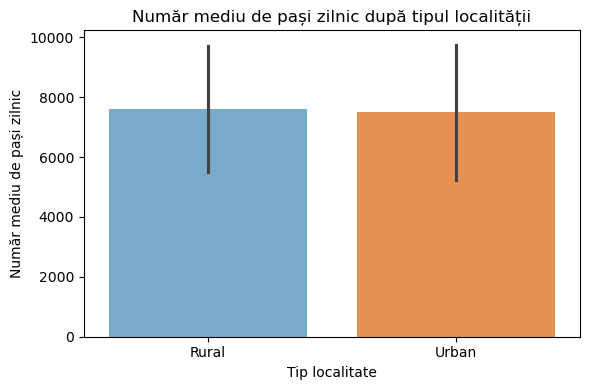

In [87]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x='Tip_Localitate',
    y='Numar_Pasi_Zilnic',
    hue='Tip_Localitate',
    palette=['#6baed6', '#fd8d3c'],
    errorbar='sd',   # deviatia standard ca bare de eroare
    dodge=False,
    legend=False
)
plt.xlabel('Tip localitate')
plt.ylabel('Număr mediu de pași zilnic')
plt.title('Număr mediu de pași zilnic după tipul localității')
plt.tight_layout()
plt.savefig('../figuri/pasi_localitate_barplot.pdf', bbox_inches='tight')
plt.show()

## Număr mediu de pași pe zi după tip ocupație

In [88]:
group_ocup = df.groupby('Tip_Ocupatie')['Numar_Pasi_Zilnic'].agg(
    Frecvență='count',
    Medie='mean',
    Mediana='median',
    Dev_std='std'
).round(2)

print(group_ocup)

               Frecvență    Medie  Mediana  Dev_std
Tip_Ocupatie                                       
Activ                 25  6996.24   6536.0  1943.66
Casnic/a              13  7222.62   7689.0  1707.77
Moderat_Activ         19  8054.63   8532.0  2274.84
Pensionar             12  7792.50   8196.0  2605.47
Sedentar              20  8096.55   8054.5  1930.32
Student               11  7071.45   6966.0  2889.97


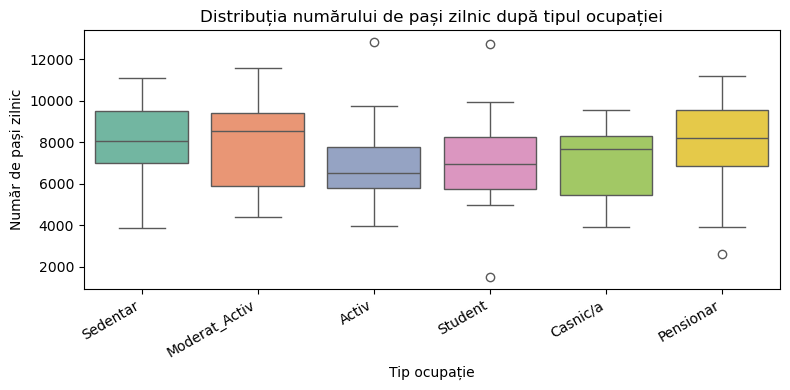

In [89]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x='Tip_Ocupatie',
    y='Numar_Pasi_Zilnic',
    hue='Tip_Ocupatie',
    palette='Set2',
    dodge=False,
    legend=False
)
plt.xlabel('Tip ocupație')
plt.ylabel('Număr de pași zilnic')
plt.title('Distribuția numărului de pași zilnic după tipul ocupației')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figuri/pasi_ocupatie_boxplot.pdf', bbox_inches='tight')
plt.show()

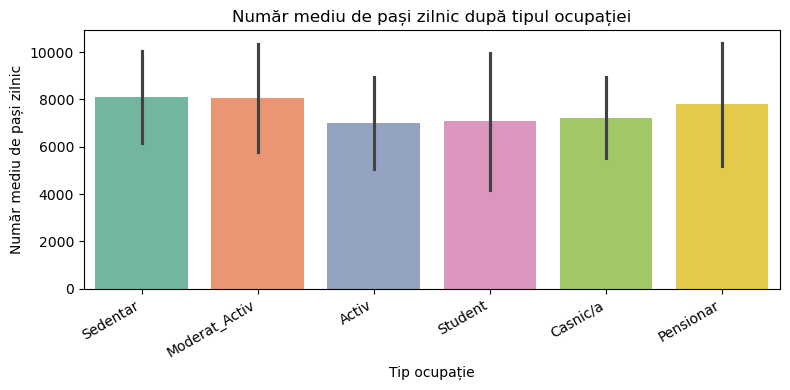

In [90]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df,
    x='Tip_Ocupatie',
    y='Numar_Pasi_Zilnic',
    hue='Tip_Ocupatie',
    palette='Set2',
    errorbar='sd',   # deviatia standard ca bare de eroare
    dodge=False,
    legend=False
)
plt.xlabel('Tip ocupație')
plt.ylabel('Număr mediu de pași zilnic')
plt.title('Număr mediu de pași zilnic după tipul ocupației')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figuri/pasi_ocupatie_barplot.pdf', bbox_inches='tight')
plt.show()

# Indicatori pentru variabilaNumar_Pasi_Zilnic

## Indicatori pentru variabila Numar_Pasi_Zilnic

In [92]:
mean_pasi = df['Numar_Pasi_Zilnic'].mean()
var_pasi = df['Numar_Pasi_Zilnic'].var(ddof=1)   # varianță eșantion
std_pasi = df['Numar_Pasi_Zilnic'].std(ddof=1)   # abatere standard eșantion
cv_pasi = std_pasi / mean_pasi * 100             # coeficient de variație (%)

print("Media: ", mean_pasi)
print("Varianta: ", var_pasi)
print("Abaterea standard: ", std_pasi)
print("Coeficientul de variatie: ", cv_pasi)

Media:  7550.65
Varianta:  4756568.876262627
Abaterea standard:  2180.9559546819432
Coeficientul de variatie:  28.884347104976964


## Indicatori pe grupe

In [97]:
def summary_group(df, group_col):
    g = df.groupby(group_col)['Numar_Pasi_Zilnic'].agg(
        Medie='mean',
        Dev_std='std'
    )
    g['CV'] = g['Dev_std'] / g['Medie'] * 100
    return g.round(2)

summary_sex = summary_group(df, 'Sex')
summary_loc = summary_group(df, 'Tip_Localitate')
summary_ocup = summary_group(df, 'Tip_Ocupatie')

print(summary_sex)
print("--------------------------------\n")
print(summary_loc)
print("--------------------------------\n")
print(summary_ocup)
print("--------------------------------\n")

            Medie  Dev_std     CV
Sex                              
Feminin   7448.11  2078.25  27.90
Masculin  7641.58  2284.09  29.89
--------------------------------

                  Medie  Dev_std     CV
Tip_Localitate                         
Rural           7622.72  2106.38  27.63
Urban           7496.28  2252.62  30.05
--------------------------------

                 Medie  Dev_std     CV
Tip_Ocupatie                          
Activ          6996.24  1943.66  27.78
Casnic/a       7222.62  1707.77  23.64
Moderat_Activ  8054.63  2274.84  28.24
Pensionar      7792.50  2605.47  33.44
Sedentar       8096.55  1930.32  23.84
Student        7071.45  2889.97  40.87
--------------------------------



# Analiza unei serii dinamice a numărului mediu de pași

In [106]:
serie_dinamica = pd.read_csv("../dataset/serie_dinamica_pasi.csv")

In [107]:
serie_dinamica.head()

,Data,Numar_Pasi_Mediu,Luna_An
0,2022-01-01,6468.66,2022-01
1,2022-02-01,6476.17,2022-02
2,2022-03-01,6998.93,2022-03
3,2022-04-01,7376.41,2022-04
4,2022-05-01,7110.21,2022-05


## Construirea seriei cronologice

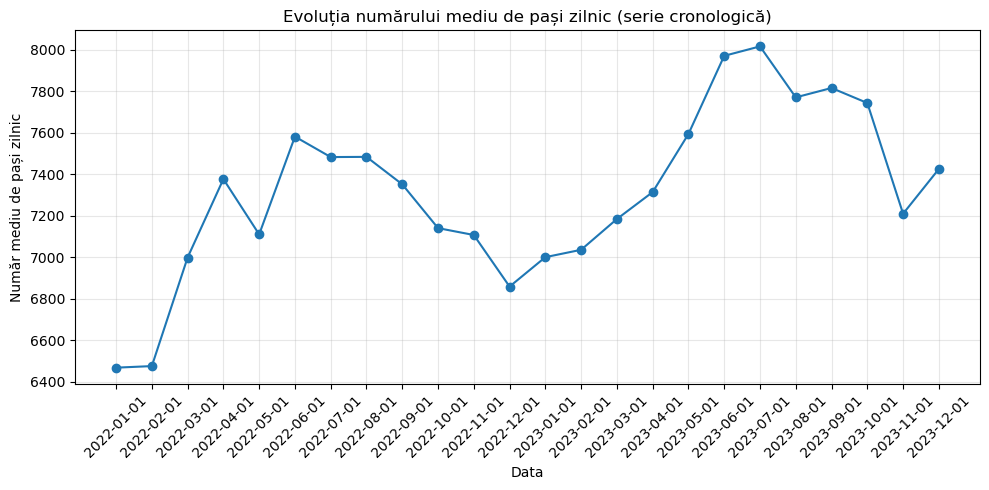

In [108]:
# Vizualizare rapidă
plt.figure(figsize=(10, 5))
plt.plot(serie_dinamica['Data'], serie_dinamica['Numar_Pasi_Mediu'], marker='o', linestyle='-')
plt.xlabel('Data')
plt.ylabel('Număr mediu de pași zilnic')
plt.title('Evoluția numărului mediu de pași zilnic (serie cronologică)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figuri/serie_dinamica_pasi.pdf', bbox_inches='tight')
plt.show()

In [110]:
sd = serie_dinamica.copy().reset_index(drop=True)

# Ordine cronologică sigură
sd = sd.sort_values('Data').reset_index(drop=True)

# Nivelul seriei: y_t
sd['y_t'] = sd['Numar_Pasi_Mediu']

# Creșteri absolute în lanț: Δy_t = y_t - y_{t-1}
sd['Delta_y_lant'] = sd['y_t'].diff()

# Creșteri absolute în bază fixă (față de prima lună): Δy_t = y_t - y_1
sd['Delta_y_baza'] = sd['y_t'] - sd.loc[0, 'y_t']

# Indici în lanț (multiplicativi): I_t/t-1 = y_t / y_{t-1}
sd['I_lant'] = sd['y_t'] / sd['y_t'].shift(1)

# Ritmuri de creștere în lanț (procente): r_t/t-1 = (y_t - y_{t-1}) / y_{t-1} * 100
sd['r_lant_%'] = (sd['y_t'].diff() / sd['y_t'].shift(1)) * 100

# Indici în bază fixă: I_t/1 = y_t / y_1
sd['I_baza'] = sd['y_t'] / sd.loc[0, 'y_t']

# Ritmuri de creștere în bază fixă (procente): r_t/1 = (y_t - y_1) / y_1 * 100
sd['r_baza_%'] = (sd['y_t'] - sd.loc[0, 'y_t']) / sd.loc[0, 'y_t'] * 100

# Rotunjim pentru prezentare
sd_round = sd.copy()
cols_to_round = ['y_t', 'Delta_y_lant', 'Delta_y_baza', 'I_lant', 'r_lant_%', 'I_baza', 'r_baza_%']
sd_round[cols_to_round] = sd_round[cols_to_round].round(2)

sd_round[['Luna_An', 'y_t', 'Delta_y_lant', 'I_lant', 'Delta_y_baza', 'I_baza', 'r_baza_%']]

,Luna_An,y_t,Delta_y_lant,I_lant,Delta_y_baza,I_baza,r_baza_%
0,2022-01,6468.66,NaN,NaN,0.00,1.00,0.00
1,2022-02,6476.17,7.51,1.00,7.51,1.00,0.12
2,2022-03,6998.93,522.76,1.08,530.27,1.08,8.20
3,2022-04,7376.41,377.48,1.05,907.75,1.14,14.03
4,2022-05,7110.21,-266.20,0.96,641.55,1.10,9.92
5,2022-06,7580.86,470.65,1.07,1112.20,1.17,17.19
6,2022-07,7482.40,-98.46,0.99,1013.74,1.16,15.67
7,2022-08,7483.34,0.94,1.00,1014.68,1.16,15.69
8,2022-09,7351.14,-132.20,0.98,882.48,1.14,13.64
9,2022-10,7140.40,-210.74,0.97,671.74,1.10,10.38


## Indicatori ai dinamici

In [111]:
sd = serie_dinamica.copy().sort_values('Data').reset_index(drop=True)
sd['y_t'] = sd['Numar_Pasi_Mediu']

# Δ_{t/t-1} și I_{t/t-1}
sd['Delta_lant'] = sd['y_t'].diff()
sd['Indice_lant'] = sd['y_t'] / sd['y_t'].shift(1) * 100  # în procente

# Δ_{t/1} și I_{t/1}
sd['Delta_baza'] = sd['y_t'] - sd.loc[0, 'y_t']
sd['Indice_baza'] = sd['y_t'] / sd.loc[0, 'y_t'] * 100

cols = ['Luna_An', 'y_t', 'Delta_lant', 'Indice_lant', 'Delta_baza', 'Indice_baza']
sd_tab = sd[cols].round(2)
print(sd_tab)

    Luna_An      y_t  Delta_lant  Indice_lant  Delta_baza  Indice_baza
0   2022-01  6468.66         NaN          NaN        0.00       100.00
1   2022-02  6476.17        7.51       100.12        7.51       100.12
2   2022-03  6998.93      522.76       108.07      530.27       108.20
3   2022-04  7376.41      377.48       105.39      907.75       114.03
4   2022-05  7110.21     -266.20        96.39      641.55       109.92
5   2022-06  7580.86      470.65       106.62     1112.20       117.19
6   2022-07  7482.40      -98.46        98.70     1013.74       115.67
7   2022-08  7483.34        0.94       100.01     1014.68       115.69
8   2022-09  7351.14     -132.20        98.23      882.48       113.64
9   2022-10  7140.40     -210.74        97.13      671.74       110.38
10  2022-11  7107.28      -33.12        99.54      638.62       109.87
11  2022-12  6858.95     -248.33        96.51      390.29       106.03
12  2023-01  7000.57      141.62       102.06      531.91       108.22
13  20

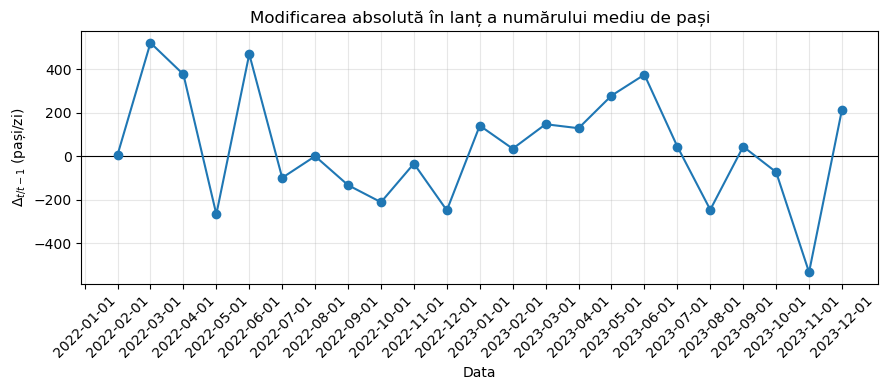

In [113]:
sd = sd_tab.copy()  # sau DataFrame-ul complet cu coloanele tale

# Ne asigurăm că avem Data ca dată calendaristică
sd_full = serie_dinamica.copy().sort_values('Data').reset_index(drop=True)
sd_full['Delta_lant'] = sd_full['Numar_Pasi_Mediu'].diff()
sd_full['Indice_lant'] = sd_full['Numar_Pasi_Mediu'] / sd_full['Numar_Pasi_Mediu'].shift(1) * 100

# 1) Creșterea absolută în lanț
plt.figure(figsize=(9, 4))
plt.axhline(0, color='black', linewidth=0.8)
plt.plot(sd_full['Data'], sd_full['Delta_lant'], marker='o', linestyle='-')
plt.title('Modificarea absolută în lanț a numărului mediu de pași')
plt.xlabel('Data')
plt.ylabel(r'$\Delta_{t/t-1}$ (pași/zi)')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figuri/delta_lant_pasi.pdf', bbox_inches='tight')
plt.show()

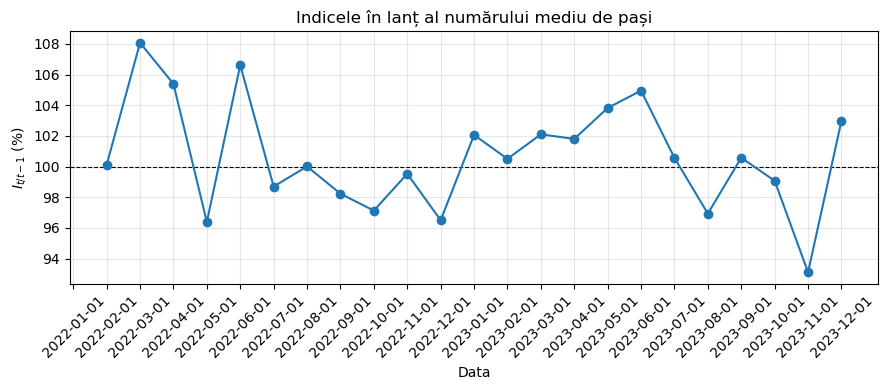

In [114]:
# 2) Indicele în lanț (procente)
plt.figure(figsize=(9, 4))
plt.axhline(100, color='black', linewidth=0.8, linestyle='--')  # linia de referință 100%
plt.plot(sd_full['Data'], sd_full['Indice_lant'], marker='o', linestyle='-')
plt.title('Indicele în lanț al numărului mediu de pași')
plt.xlabel('Data')
plt.ylabel(r'$I_{t/t-1}$ (%)')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figuri/indice_lant_pasi.pdf', bbox_inches='tight')
plt.show()

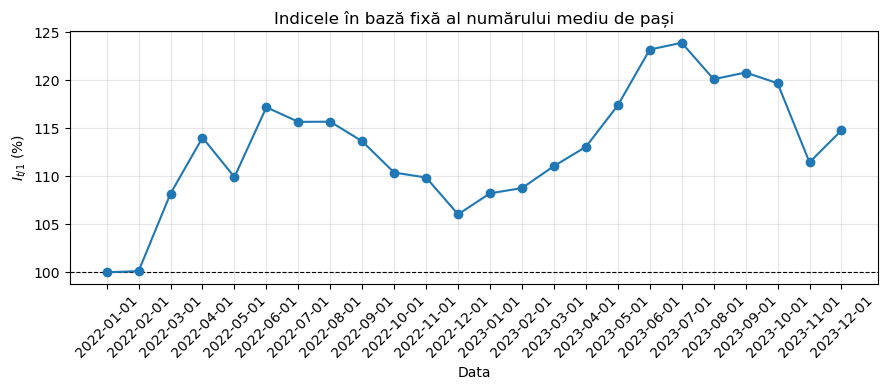

In [115]:
sd_full['Indice_baza'] = sd_full['Numar_Pasi_Mediu'] / sd_full.loc[0, 'Numar_Pasi_Mediu'] * 100

plt.figure(figsize=(9, 4))
plt.axhline(100, color='black', linewidth=0.8, linestyle='--')
plt.plot(sd_full['Data'], sd_full['Indice_baza'], marker='o', linestyle='-')
plt.title('Indicele în bază fixă al numărului mediu de pași')
plt.xlabel('Data')
plt.ylabel(r'$I_{t/1}$ (%)')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figuri/indice_baza_pasi.pdf', bbox_inches='tight')
plt.show()

## Indicatori medii ai seriei

In [118]:
sd = serie_dinamica.copy().sort_values('Data').reset_index(drop=True)
y = sd['Numar_Pasi_Mediu'].values
T = len(y)

print("="*60)
print("INDICATORI MEDII AI SERIEI CRONOLOGICE")
print("="*60)

# Media seriei
y_bar = y.mean()
print(f"\n1. Media seriei:")
print(f"   ȳ = (1/{T}) * Σ y_t")
print(f"   ȳ = {y_bar:.2f} pași/zi")

# Modificarea medie absolută
y_1 = y[0]
y_T = y[-1]
Delta_medie = (y_T - y_1) / (T - 1)
print(f"\n2. Modificarea medie absolută:")
print(f"   Δ̄ = (y_T - y_1) / (T - 1)")
print(f"   Δ̄ = ({y_T:.2f} - {y_1:.2f}) / ({T} - 1)")
print(f"   Δ̄ = {y_T - y_1:.2f} / {T - 1}")
print(f"   Δ̄ = {Delta_medie:.2f} pași/zi/lună")

# Rata medie de creștere
rata_medie = (y_T / y_1)**(1/(T - 1)) - 1  # în fracție
rata_medie_proc = rata_medie * 100
print(f"\n3. Rata medie a creșterii:")
print(f"   ī = ᵀ⁻¹√(y_T / y_1) - 1")
print(f"   ī = ²³√({y_T:.2f} / {y_1:.2f}) - 1")
print(f"   ī = ²³√{y_T / y_1:.4f} - 1")
print(f"   ī = {rata_medie:.6f}")
print(f"   ī = {rata_medie_proc:.2f}% pe lună")

print("\n" + "="*60)
print("REZUMAT")
print("="*60)
print(f"Media seriei:              {y_bar:.2f} pași/zi")
print(f"Modificarea medie absolută: {Delta_medie:.2f} pași/zi/lună")
print(f"Rata medie de creștere:     {rata_medie_proc:.2f}% pe lună")
print("="*60)

INDICATORI MEDII AI SERIEI CRONOLOGICE

1. Media seriei:
   ȳ = (1/24) * Σ y_t
   ȳ = 7312.91 pași/zi

2. Modificarea medie absolută:
   Δ̄ = (y_T - y_1) / (T - 1)
   Δ̄ = (7425.09 - 6468.66) / (24 - 1)
   Δ̄ = 956.43 / 23
   Δ̄ = 41.58 pași/zi/lună

3. Rata medie a creșterii:
   ī = ᵀ⁻¹√(y_T / y_1) - 1
   ī = ²³√(7425.09 / 6468.66) - 1
   ī = ²³√1.1479 - 1
   ī = 0.006013
   ī = 0.60% pe lună

REZUMAT
Media seriei:              7312.91 pași/zi
Modificarea medie absolută: 41.58 pași/zi/lună
Rata medie de creștere:     0.60% pe lună
